# A Probing Study of Contextual Embeddings for Sarcasm Detection

## 1. Data Preparation

In [4]:
!pip install vaderSentiment spacy --quiet
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import pandas as pd
import numpy as np
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from google.colab import drive
import os
import json

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Set your paths — adjust the folder name to wherever your files are
DATA_PATH  = '/content/drive/MyDrive/CP Project/'
TRAIN_FILE = DATA_PATH + 'SARC-train-balanced.csv'
TEST_FILE  = DATA_PATH + 'SARC-test-balanced.csv'
SAVE_PATH  = DATA_PATH  # we'll save all outputs here

os.makedirs(SAVE_PATH, exist_ok=True)

In [8]:
# ── 2. Load raw file ─────────────────────────────────────────
train_raw = pd.read_csv(TRAIN_FILE)

print("Columns:", train_raw.columns.tolist())
print("Shape:  ", train_raw.shape)
print()
print(train_raw.head(3).to_string())

Columns: ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']
Shape:   (1010826, 10)

   label                                                                                                                    comment     author subreddit  score  ups  downs     date          created_utc                                                                                                                          parent_comment
0      0                                                                                                                 NC and NH.  Trumpbart  politics      2   -1     -1  2016-10  2016-10-16 23:55:23                                                        Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well.
1      0                                                 You do know west teams play against west teams more than east teams right?  Shbshb906       nba     -4   -1     -1  2016-11 

In [9]:
# ── 3. Standardise columns ───────────────────────────────────
def standardise(df):
    df = df.copy()

    rename_map = {
        'comment':   'text',
        'label':     'label',
        'subreddit': 'subreddit',
    }
    rename_map = {k: v for k, v in rename_map.items()
                  if k in df.columns}
    df = df.rename(columns=rename_map)

    cols_to_keep = [c for c in ['text', 'label', 'subreddit']
                    if c in df.columns]
    df = df[cols_to_keep]

    df = df.dropna(subset=['text', 'label'])
    df['label'] = df['label'].astype(int)
    df['text']  = df['text'].astype(str)

    return df

train_df = standardise(train_raw)

print("After standardising:")
print("Shape:", train_df.shape)
print("Label distribution:\n", train_df['label'].value_counts())
print()
print(train_df.head(3).to_string())

After standardising:
Shape: (1010771, 3)
Label distribution:
 label
0    505403
1    505368
Name: count, dtype: int64

                                                                                                                        text  label subreddit
0                                                                                                                 NC and NH.      0  politics
1                                                 You do know west teams play against west teams more than east teams right?      0       nba
2  They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1      0       nfl


In [10]:
# ── 4. Stratified sample: 5,000 sarcastic + 5,000 literal ───
N_PER_CLASS = 5000
RANDOM_SEED = 42

def stratified_sample(df, label_val, n, seed=42):
    """
    Sample n rows with a given label, stratified by subreddit.
    Falls back to simple random sample if subreddit is missing
    or a subreddit has too few rows.
    """
    subset = df[df['label'] == label_val].copy()

    if 'subreddit' not in subset.columns:
        print(f"  No subreddit column — random sampling")
        return subset.sample(n=min(n, len(subset)),
                             random_state=seed)

    sub_counts     = subset['subreddit'].value_counts()
    sub_props      = sub_counts / sub_counts.sum()
    sub_allocs     = (sub_props * n).astype(int)

    print(f"  label={label_val}: {len(subset)} rows across "
          f"{len(sub_counts)} subreddits")

    samples = []
    for sub, alloc in sub_allocs.items():
        if alloc == 0:
            continue
        sub_df = subset[subset['subreddit'] == sub]
        alloc  = min(alloc, len(sub_df))
        samples.append(
            sub_df.sample(n=alloc, random_state=seed)
        )

    sampled = pd.concat(samples, ignore_index=True)

    # Top up if rounding left us short
    if len(sampled) < n:
        already_idx = set(sampled.index)
        remaining   = subset[~subset.index.isin(already_idx)]
        shortfall   = n - len(sampled)
        if len(remaining) >= shortfall:
            extra   = remaining.sample(n=shortfall,
                                       random_state=seed)
            sampled = pd.concat([sampled, extra],
                                ignore_index=True)

    # Trim to exactly n
    return sampled.sample(
        n=min(n, len(sampled)), random_state=seed
    )


print("Sampling sarcastic sentences...")
sarcastic_sample = stratified_sample(
    train_df, 1, N_PER_CLASS, RANDOM_SEED
)

print("Sampling literal sentences...")
literal_sample = stratified_sample(
    train_df, 0, N_PER_CLASS, RANDOM_SEED
)

# Combine and shuffle
dataset = pd.concat(
    [sarcastic_sample, literal_sample], ignore_index=True
)
dataset = dataset.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

print()
print("Final dataset shape:", dataset.shape)
print("Label distribution:\n", dataset['label'].value_counts())
if 'subreddit' in dataset.columns:
    print("\nSubreddit spread (top 10):\n",
          dataset['subreddit'].value_counts().head(10))

Sampling sarcastic sentences...
  label=1: 505368 rows across 8993 subreddits
Sampling literal sentences...
  label=0: 505403 rows across 12836 subreddits

Final dataset shape: (10000, 3)
Label distribution:
 label
0    5000
1    5000
Name: count, dtype: int64

Subreddit spread (top 10):
 subreddit
AskReddit          792
politics           472
worldnews          328
leagueoflegends    243
pcmasterrace       232
funny              228
pics               208
news               193
GlobalOffensive    172
nba                170
Name: count, dtype: int64


In [11]:
# ── 5. Identify sarcasm-critical tokens ──────────────────────
nlp      = spacy.load("en_core_web_sm")
analyzer = SentimentIntensityAnalyzer()

def get_critical_word(text):
    """
    Finds the sarcasm-critical token in a sentence.

    Primary method: among all content words (ADJ, ADV, NOUN,
    VERB), pick the one whose individual VADER sentiment most
    contradicts the overall sentence sentiment.

    incongruity = word_sentiment - sentence_sentiment

    High score = word is more positive than the sentence
    overall = likely the irony trigger.

    Fallback 1: most positive ADJ or ADV in the sentence.
    Fallback 2: most positive any content word.

    Returns:
        critical_word  : token text (str) or None
        critical_index : token position in sentence (int) or None
        critical_pos   : POS tag (str) or None
        incongruity    : incongruity score (float)
        method         : which method was used (str)
    """
    text = str(text).strip()
    if not text:
        return None, None, None, 0.0, 'empty'

    # Overall sentence sentiment
    sent_score = analyzer.polarity_scores(text)['compound']

    doc = nlp(text)

    # ── Primary: incongruity score ───────────────────────────
    best = {
        'word': None, 'idx': None, 'pos': None,
        'score': -999, 'method': 'incongruity'
    }

    for token in doc:
        if token.pos_ not in ['ADJ', 'ADV', 'NOUN', 'VERB']:
            continue
        if token.is_stop or token.is_punct:
            continue
        word_score  = analyzer.polarity_scores(
            token.text)['compound']
        incongruity = word_score - sent_score
        if incongruity > best['score']:
            best = {
                'word':   token.text,
                'idx':    token.i,
                'pos':    token.pos_,
                'score':  incongruity,
                'method': 'incongruity'
            }

    # ── Fallback 1: most positive ADJ / ADV ─────────────────
    if best['word'] is None or best['score'] <= 0:
        adj_adv = [
            (t.text, t.i, t.pos_,
             analyzer.polarity_scores(t.text)['compound'])
            for t in doc
            if t.pos_ in ['ADJ', 'ADV']
            and not t.is_stop and not t.is_punct
        ]
        if adj_adv:
            adj_adv.sort(key=lambda x: x[3], reverse=True)
            w, i, pos, sc = adj_adv[0]
            best = {
                'word': w, 'idx': i, 'pos': pos,
                'score': sc, 'method': 'fallback_adj_adv'
            }

    # ── Fallback 2: most positive any content word ───────────
    if best['word'] is None:
        content = [
            (t.text, t.i, t.pos_,
             analyzer.polarity_scores(t.text)['compound'])
            for t in doc
            if t.pos_ in ['ADJ', 'ADV', 'NOUN', 'VERB']
            and not t.is_stop and not t.is_punct
        ]
        if content:
            content.sort(key=lambda x: x[3], reverse=True)
            w, i, pos, sc = content[0]
            best = {
                'word': w, 'idx': i, 'pos': pos,
                'score': sc, 'method': 'fallback_any_content'
            }

    return (
        best['word'], best['idx'], best['pos'],
        best['score'], best['method']
    )


# Apply to sarcastic sentences only
print("Identifying sarcasm-critical tokens...")
print("Running spaCy + VADER on 5,000 sentences — ~3-5 min\n")

sarcastic_only = dataset[dataset['label'] == 1]\
                        .copy().reset_index(drop=True)

results = sarcastic_only['text'].apply(get_critical_word)

sarcastic_only['critical_word']  = results.apply(lambda x: x[0])
sarcastic_only['critical_index'] = results.apply(lambda x: x[1])
sarcastic_only['critical_pos']   = results.apply(lambda x: x[2])
sarcastic_only['incongruity']    = results.apply(lambda x: x[3])
sarcastic_only['method']         = results.apply(lambda x: x[4])

Identifying sarcasm-critical tokens...
Running spaCy + VADER on 5,000 sentences — ~3-5 min



In [12]:
# ── 6. Sanity checks ─────────────────────────────────────────
print("Method distribution:")
print(sarcastic_only['method'].value_counts())
print()

coverage = sarcastic_only['critical_word'].notna().sum()
print(f"Critical word found: {coverage} / "
      f"{len(sarcastic_only)} "
      f"({coverage/len(sarcastic_only)*100:.1f}%)")
print()

print("Top 20 most common critical words:")
print(sarcastic_only['critical_word'].value_counts().head(20))
print()

print("POS distribution of critical words:")
print(sarcastic_only['critical_pos'].value_counts())
print()

print("Incongruity score stats:")
print(sarcastic_only['incongruity'].describe().round(3))

Method distribution:
method
incongruity         3182
fallback_adj_adv    1818
Name: count, dtype: int64

Critical word found: 4787 / 5000 (95.7%)

Top 20 most common critical words:
critical_word
good          100
better         64
sure           62
great          60
forgot         50
right          43
want           39
know           39
obviously      38
think          37
best           37
totally        36
Maybe          34
pretty         32
clearly        29
free           27
definitely     27
Good           26
mean           25
true           24
Name: count, dtype: int64

POS distribution of critical words:
critical_pos
ADJ     1711
VERB    1244
NOUN    1204
ADV      628
Name: count, dtype: int64

Incongruity score stats:
count    5000.000
mean      -42.362
std       201.813
min      -999.000
25%         0.000
50%         0.000
75%         0.440
max         1.497
Name: incongruity, dtype: float64


In [13]:
# ── 7. Spot check — read through these manually ──────────────
print("=" * 65)
print("SPOT CHECK — do these critical words look right?")
print("=" * 65)

spot = sarcastic_only[
    sarcastic_only['critical_word'].notna()
].sample(20, random_state=42)

for _, row in spot.iterrows():
    text = str(row['text'])
    word = str(row['critical_word'])
    highlighted = text.replace(word, f"[[ {word} ]]", 1)
    print(f"→ {highlighted}")
    print(f"  Word: '{word}' | "
          f"POS: {row['critical_pos']} | "
          f"Incongruity: {row['incongruity']:.3f} | "
          f"Method: {row['method']}")
    print()

SPOT CHECK — do these critical words look right?
→ didnt u [[ know ]] u need a penis to ghost-bust?
  Word: 'know' | POS: VERB | Incongruity: 0.000 | Method: incongruity

→ Turns out [[ old ]] Ronny was an Anarchist
  Word: 'old' | POS: ADJ | Incongruity: 0.000 | Method: fallback_adj_adv

→ Because Reddit never downvotes anything constructive and/or [[ useful ]].
  Word: 'useful' | POS: ADJ | Incongruity: 0.440 | Method: fallback_adj_adv

→ Ah yes, the original and [[ hilarious ]] attack helicopter joke
  Word: 'hilarious' | POS: ADJ | Incongruity: 0.402 | Method: fallback_adj_adv

→ This must have been [[ fun ]] for passengers in the terminal to watch as they were boarding their flights.
  Word: 'fun' | POS: ADJ | Incongruity: 0.511 | Method: fallback_adj_adv

→ Pfft, big deal, [[ pretty ]] sure the Pats have released and re-signed Gronk's little brother at least twice that many times
  Word: 'pretty' | POS: ADV | Incongruity: 0.494 | Method: fallback_adj_adv

→ Yeah, let's [[ celebra

In [14]:
def get_critical_word_strict(text):
    """
    Stricter version — only returns a result when confident.

    Conditions for a valid critical word:
    1. Must be ADJ or ADV only (not NOUN or VERB)
    2. Word VADER score must be clearly positive (> 0.3)
    3. Sentence VADER score must be clearly negative (< -0.1)
       OR sentence is neutral but word is strongly positive (> 0.5)
    4. Incongruity score must be > 0.3

    Returns None if no confident candidate found.
    """
    text = str(text).strip()
    if not text:
        return None, None, None, 0.0, 'empty'

    sent_score = analyzer.polarity_scores(text)['compound']
    doc = nlp(text)

    candidates = []
    for token in doc:
        if token.pos_ not in ['ADJ', 'ADV']:
            continue
        if token.is_stop or token.is_punct:
            continue
        if len(token.text) < 3:  # skip very short words
            continue

        word_score  = analyzer.polarity_scores(token.text)['compound']
        incongruity = word_score - sent_score

        # Must meet all three conditions
        word_positive    = word_score > 0.3
        sentence_not_pos = sent_score < 0.1
        strong_incongruity = incongruity > 0.3

        if word_positive and sentence_not_pos and strong_incongruity:
            candidates.append((
                token.text, token.i, token.pos_,
                incongruity, 'strict'
            ))

    if not candidates:
        return None, None, None, 0.0, 'no_confident_candidate'

    # Pick the one with highest incongruity
    candidates.sort(key=lambda x: x[3], reverse=True)
    w, i, pos, sc, method = candidates[0]
    return w, i, pos, sc, method

In [15]:
print("Applying strict critical word detection...")
results_strict = sarcastic_only['text'].apply(get_critical_word_strict)

sarcastic_only['critical_word']  = results_strict.apply(lambda x: x[0])
sarcastic_only['critical_index'] = results_strict.apply(lambda x: x[1])
sarcastic_only['critical_pos']   = results_strict.apply(lambda x: x[2])
sarcastic_only['incongruity']    = results_strict.apply(lambda x: x[3])
sarcastic_only['method']         = results_strict.apply(lambda x: x[4])

# How many did we get?
found = sarcastic_only['critical_word'].notna().sum()
print(f"Critical word found (strict): {found} / {len(sarcastic_only)} "
      f"({found/len(sarcastic_only)*100:.1f}%)")

# Spot check again
print("\nSPOT CHECK — strict version:")
print("=" * 65)
spot = sarcastic_only[
    sarcastic_only['critical_word'].notna()
].sample(20, random_state=42)

for _, row in spot.iterrows():
    text = str(row['text'])
    word = str(row['critical_word'])
    highlighted = text.replace(word, f"[[ {word} ]]", 1)
    print(f"→ {highlighted}")
    print(f"  Word: '{word}' | "
          f"Incongruity: {row['incongruity']:.3f}")
    print()

Applying strict critical word detection...
Critical word found (strict): 185 / 5000 (3.7%)

SPOT CHECK — strict version:
→ Quality of life behind the Iron Curtain was really outpacing the West but no one knew it because [[ powerful ]] people spent a lot of money to hide that fact.
  Word: 'powerful' | Incongruity: 0.460

→ Oh [[ sure ]] lets just fire tear gas into a crowd of pissed protesters, totally will be fine.
  Word: 'sure' | Incongruity: 0.948

→ I wonder if there is a [[ positive ]] correlation between poverty and poor education.
  Word: 'positive' | Incongruity: 0.979

→ Well, guess ill have to kill every [[ fresh ]] spawn with cargo pants now.
  Word: 'fresh' | Incongruity: 0.943

→ Mmm nothing [[ better ]] than stubble rubbing against my, uh, stubble.
  Word: 'better' | Incongruity: 0.782

→ Hostility changes nobody's point of view,you know.And it *would* come out [[ nicely ]],thank you!
  Word: 'nicely' | Incongruity: 1.025

→ Onviously if it is [[ good ]] for alabama and 

In [16]:
# ── 8. Save to Drive ─────────────────────────────────────────

# Main dataset — all 10,000 sentences
dataset_path = SAVE_PATH + 'dataset_10k.csv'
dataset.to_csv(dataset_path, index=False)
print(f"Saved: {dataset_path}  "
      f"({os.path.getsize(dataset_path)/1024:.0f} KB)")

# Sarcastic sentences with critical word annotations
critical_path = SAVE_PATH + 'sarcastic_with_critical_words.csv'
sarcastic_only.to_csv(critical_path, index=False)
print(f"Saved: {critical_path}  "
      f"({os.path.getsize(critical_path)/1024:.0f} KB)")

# Summary log
summary = {
    'total_sentences':        int(len(dataset)),
    'sarcastic':              int((dataset['label']==1).sum()),
    'literal':                int((dataset['label']==0).sum()),
    'random_seed':            RANDOM_SEED,
    'source':                 'train-balanced.csv only',
    'critical_word_coverage': f"{coverage}/{len(sarcastic_only)}",
    'method_distribution':    sarcastic_only['method']
                              .value_counts().to_dict(),
}

summary_path = SAVE_PATH + 'phase1_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Saved: {summary_path}")

print("\nPhase 1 complete.")

Saved: /content/drive/MyDrive/CP Project/dataset_10k.csv  (682 KB)
Saved: /content/drive/MyDrive/CP Project/sarcastic_with_critical_words.csv  (490 KB)
Saved: /content/drive/MyDrive/CP Project/phase1_summary.json

Phase 1 complete.


## 2. BERT Probing (RQ1)

In [17]:
# ── 0. Imports & setup ───────────────────────────────────────
!pip install transformers --quiet

import torch
import numpy as np
import pandas as pd
from transformers import BertTokenizer, BertModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = '/content/drive/MyDrive/CP Project/'
TRAIN_FILE = DATA_PATH + 'SARC-train-balanced.csv'
TEST_FILE  = DATA_PATH + 'SARC-test-balanced.csv'
SAVE_PATH  = DATA_PATH  # we'll save all outputs here
RANDOM_SEED = 42

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found — go to Runtime > Change runtime type "
          "> T4 GPU and restart")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: Tesla T4


In [18]:
# ── 1. Load dataset from Drive ───────────────────────────────
dataset = pd.read_csv(SAVE_PATH + 'dataset_10k.csv')

print("Dataset loaded:")
print("Shape:", dataset.shape)
print("Label distribution:\n", dataset['label'].value_counts())
print()
print(dataset.head(3).to_string())

print("Dataset loaded:")
print("Shape:", dataset.shape)
print("Label distribution:\n", dataset['label'].value_counts())
print()
print(dataset.head(3).to_string())

Dataset loaded:
Shape: (10000, 3)
Label distribution:
 label
0    5000
1    5000
Name: count, dtype: int64

                                                                                                                                                                                                    text  label        subreddit
0  If you read the article, it goes over how Republicans still do relatively well in gubernatorial elections in Vermont, kind of like Massachusetts in that regard, despite how liberal the state leans.      0         politics
1                                                                                                                                                                                  Welcome to democracy!      1        worldnews
2                                                                                                                                      They'll investigate themselves and find they did nothing wrong...      1  MakingaM

In [19]:
# ── 2. Load pre-trained BERT ─────────────────────────────────
print("Loading BERT tokenizer and model...")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model     = BertModel.from_pretrained(
    'bert-base-uncased',
    output_hidden_states=True  # gives us all 12 layers
)

model = model.to(device)
model.eval()  # freeze — no dropout, no gradient updates

print("BERT loaded.")
print(f"Number of layers: {model.config.num_hidden_layers}")
print(f"Hidden size:      {model.config.hidden_size}")

Loading BERT tokenizer and model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded.
Number of layers: 12
Hidden size:      768


In [20]:
# ── 3. Extract [CLS] representations from all 12 layers ──────
# This is the slow cell — ~10-15 min on T4 GPU
# Processes sentences in batches to avoid OOM errors
# Saves to Drive immediately when done

def extract_cls_representations(texts, tokenizer, model,
                                 device, batch_size=32,
                                 max_length=128):
    """
    Passes all texts through frozen BERT and extracts the
    [CLS] token representation from each of the 12 layers.

    Returns:
        all_hidden_states : list of 12 arrays, each of shape
                            (n_sentences, 768)
                            Index 0 = layer 1, index 11 = layer 12
    """
    n         = len(texts)
    n_layers  = model.config.num_hidden_layers  # 12
    hidden_sz = model.config.hidden_size         # 768

    # Pre-allocate — one array per layer
    all_cls = [np.zeros((n, hidden_sz), dtype=np.float32)
               for _ in range(n_layers)]

    n_batches = (n + batch_size - 1) // batch_size

    with torch.no_grad():
        for batch_idx in range(n_batches):
            start = batch_idx * batch_size
            end   = min(start + batch_size, n)
            batch_texts = texts[start:end].tolist()

            # Tokenise
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            )
            input_ids      = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # hidden_states is a tuple of 13 tensors:
            # index 0 = embedding layer
            # index 1-12 = transformer layers 1-12
            hidden_states = outputs.hidden_states

            # Extract [CLS] token (position 0) from each layer
            for layer_idx in range(n_layers):
                # hidden_states[layer_idx + 1] skips embedding layer
                cls_vec = hidden_states[layer_idx + 1][:, 0, :]
                all_cls[layer_idx][start:end] = \
                    cls_vec.cpu().numpy()

            # Progress update every 10 batches
            if (batch_idx + 1) % 10 == 0 or \
               (batch_idx + 1) == n_batches:
                print(f"  Batch {batch_idx+1}/{n_batches} "
                      f"({end}/{n} sentences)")

    return all_cls


print("Extracting pre-trained BERT representations...")
print("This will take ~10-15 minutes on GPU — let it run\n")

pretrained_cls = extract_cls_representations(
    texts      = dataset['text'],
    tokenizer  = tokenizer,
    model      = model,
    device     = device,
    batch_size = 32,
    max_length = 128
)

print(f"\nDone. Extracted {len(pretrained_cls)} layers")
print(f"Each layer shape: {pretrained_cls[0].shape}")

Extracting pre-trained BERT representations...
This will take ~10-15 minutes on GPU — let it run

  Batch 10/313 (320/10000 sentences)
  Batch 20/313 (640/10000 sentences)
  Batch 30/313 (960/10000 sentences)
  Batch 40/313 (1280/10000 sentences)
  Batch 50/313 (1600/10000 sentences)
  Batch 60/313 (1920/10000 sentences)
  Batch 70/313 (2240/10000 sentences)
  Batch 80/313 (2560/10000 sentences)
  Batch 90/313 (2880/10000 sentences)
  Batch 100/313 (3200/10000 sentences)
  Batch 110/313 (3520/10000 sentences)
  Batch 120/313 (3840/10000 sentences)
  Batch 130/313 (4160/10000 sentences)
  Batch 140/313 (4480/10000 sentences)
  Batch 150/313 (4800/10000 sentences)
  Batch 160/313 (5120/10000 sentences)
  Batch 170/313 (5440/10000 sentences)
  Batch 180/313 (5760/10000 sentences)
  Batch 190/313 (6080/10000 sentences)
  Batch 200/313 (6400/10000 sentences)
  Batch 210/313 (6720/10000 sentences)
  Batch 220/313 (7040/10000 sentences)
  Batch 230/313 (7360/10000 sentences)
  Batch 240/313 (

In [21]:
# ── 4. Save representations to Drive immediately ─────────────
# Do this right after extraction — don't risk losing them

print("Saving representations to Drive...")

reps_path = SAVE_PATH + 'pretrained_cls_representations/'
os.makedirs(reps_path, exist_ok=True)

for layer_idx, layer_reps in enumerate(pretrained_cls):
    layer_num  = layer_idx + 1  # 1-indexed for clarity
    layer_path = reps_path + f'layer_{layer_num:02d}.npy'
    np.save(layer_path, layer_reps)

print(f"Saved 12 layer files to: {reps_path}")
print("Files:")
for f in sorted(os.listdir(reps_path)):
    size_mb = os.path.getsize(reps_path + f) / (1024*1024)
    print(f"  {f}  ({size_mb:.1f} MB)")

Saving representations to Drive...
Saved 12 layer files to: /content/drive/MyDrive/CP Project/pretrained_cls_representations/
Files:
  layer_01.npy  (29.3 MB)
  layer_02.npy  (29.3 MB)
  layer_03.npy  (29.3 MB)
  layer_04.npy  (29.3 MB)
  layer_05.npy  (29.3 MB)
  layer_06.npy  (29.3 MB)
  layer_07.npy  (29.3 MB)
  layer_08.npy  (29.3 MB)
  layer_09.npy  (29.3 MB)
  layer_10.npy  (29.3 MB)
  layer_11.npy  (29.3 MB)
  layer_12.npy  (29.3 MB)


In [22]:
# ── 5. Also save labels for use in probing ───────────────────
labels = dataset['label'].values
np.save(SAVE_PATH + 'labels.npy', labels)
print(f"Saved labels: {labels.shape}")
print(f"Sarcastic (1): {labels.sum()}  "
      f"Literal (0): {(labels==0).sum()}")

Saved labels: (10000,)
Sarcastic (1): 5000  Literal (0): 5000


In [23]:
# ── 6. Train probes on each layer ────────────────────────────
# For each of the 12 layers:
#   - Split into 80% train / 20% test (same split every time)
#   - Standardise features
#   - Train logistic regression
#   - Record accuracy, F1, and per-sentence confidence margin
#
# The confidence margin = distance from decision boundary
# = how certain the probe is about each sentence
# We use this later in Phase 3 for feature correlation

RANDOM_SEED = 42

# Fixed train/test split — same across all layers
train_idx, test_idx = train_test_split(
    np.arange(len(labels)),
    test_size   = 0.2,
    random_state = RANDOM_SEED,
    stratify    = labels
)

print(f"Train size: {len(train_idx)}")
print(f"Test size:  {len(test_idx)}")
print()

# Store results
layer_results = []          # accuracy + F1 per layer
confidence_margins = {}     # per-sentence margin per layer

print("Training probes on each layer...")
print("-" * 50)

for layer_idx in range(12):
    layer_num = layer_idx + 1

    X = pretrained_cls[layer_idx]   # (10000, 768)
    y = labels                       # (10000,)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Standardise — important for logistic regression
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Train probe
    probe = LogisticRegression(
        max_iter    = 1000,
        random_state = RANDOM_SEED,
        C           = 1.0
    )
    probe.fit(X_train, y_train)

    # Evaluate
    y_pred = probe.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)

    # Confidence margin for ALL sentences (not just test)
    # decision_function gives signed distance from boundary
    # We standardise all data for this
    X_all_scaled = scaler.transform(X)
    margins      = probe.decision_function(X_all_scaled)
    confidence_margins[layer_num] = margins

    layer_results.append({
        'layer':    layer_num,
        'accuracy': acc,
        'f1':       f1
    })

    print(f"Layer {layer_num:2d} — "
          f"Accuracy: {acc:.4f}  F1: {f1:.4f}")

print("-" * 50)
results_df = pd.DataFrame(layer_results)
best_layer = results_df.loc[results_df['accuracy'].idxmax()]
print(f"\nBest layer: {int(best_layer['layer'])}  "
      f"(Accuracy: {best_layer['accuracy']:.4f}  "
      f"F1: {best_layer['f1']:.4f})")

Train size: 8000
Test size:  2000

Training probes on each layer...
--------------------------------------------------
Layer  1 — Accuracy: 0.6460  F1: 0.6384
Layer  2 — Accuracy: 0.6500  F1: 0.6381
Layer  3 — Accuracy: 0.6520  F1: 0.6423
Layer  4 — Accuracy: 0.6450  F1: 0.6403
Layer  5 — Accuracy: 0.6435  F1: 0.6394
Layer  6 — Accuracy: 0.6475  F1: 0.6398
Layer  7 — Accuracy: 0.6325  F1: 0.6282
Layer  8 — Accuracy: 0.6490  F1: 0.6404
Layer  9 — Accuracy: 0.6515  F1: 0.6474
Layer 10 — Accuracy: 0.6575  F1: 0.6580
Layer 11 — Accuracy: 0.6670  F1: 0.6647
Layer 12 — Accuracy: 0.6615  F1: 0.6653
--------------------------------------------------

Best layer: 11  (Accuracy: 0.6670  F1: 0.6647)


In [24]:
# ── 7. Random baseline probe ─────────────────────────────────
# Train same probe on random vectors — should be ~50% accuracy
# Confirms that above-chance results in step 6 are real

print("Training random baseline probe...")

np.random.seed(RANDOM_SEED)
X_random      = np.random.randn(len(labels), 768).astype(np.float32)
X_rand_train  = X_random[train_idx]
X_rand_test   = X_random[test_idx]
y_train_rand  = labels[train_idx]
y_test_rand   = labels[test_idx]

scaler_rand   = StandardScaler()
X_rand_train  = scaler_rand.fit_transform(X_rand_train)
X_rand_test   = scaler_rand.transform(X_rand_test)

baseline_probe = LogisticRegression(
    max_iter=1000, random_state=RANDOM_SEED
)
baseline_probe.fit(X_rand_train, y_train_rand)
baseline_acc = accuracy_score(
    y_test_rand, baseline_probe.predict(X_rand_test)
)

print(f"Random baseline accuracy: {baseline_acc:.4f}")
print(f"(Should be close to 0.50)")

Training random baseline probe...
Random baseline accuracy: 0.4880
(Should be close to 0.50)


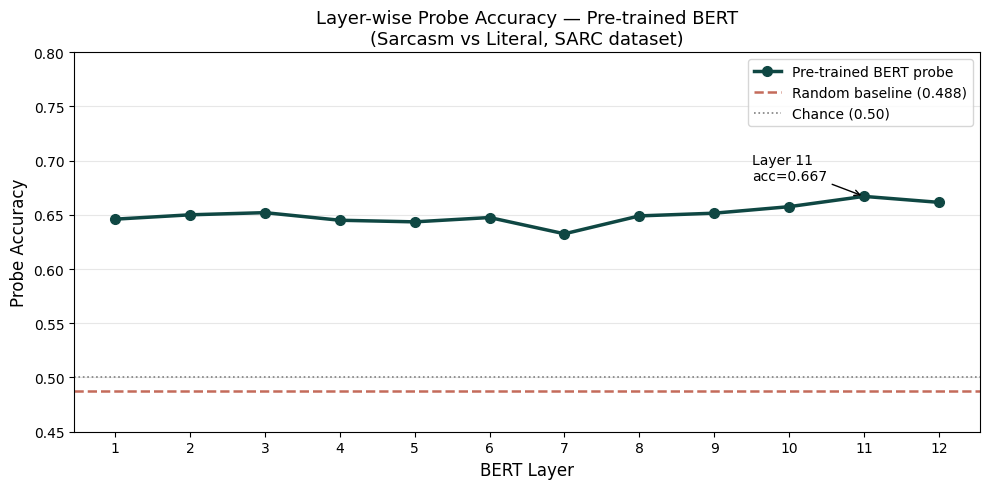

Plot saved.


In [25]:
# ── 8. Plot the layer-wise accuracy curve ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results_df['layer'], results_df['accuracy'],
        marker='o', linewidth=2.5, markersize=7,
        color='#0F4743', label='Pre-trained BERT probe')

ax.axhline(y=baseline_acc, color='#C46B5A',
           linestyle='--', linewidth=1.8,
           label=f'Random baseline ({baseline_acc:.3f})')

ax.axhline(y=0.5, color='gray',
           linestyle=':', linewidth=1.2,
           label='Chance (0.50)')

# Annotate best layer
best_row = results_df.loc[results_df['accuracy'].idxmax()]
ax.annotate(
    f"Layer {int(best_row['layer'])}\n"
    f"acc={best_row['accuracy']:.3f}",
    xy=(best_row['layer'], best_row['accuracy']),
    xytext=(best_row['layer'] - 1.5,
            best_row['accuracy'] + 0.015),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black'),
    color='black'
)

ax.set_xlabel('BERT Layer', fontsize=12)
ax.set_ylabel('Probe Accuracy', fontsize=12)
ax.set_title(
    'Layer-wise Probe Accuracy — Pre-trained BERT\n'
    '(Sarcasm vs Literal, SARC dataset)',
    fontsize=13
)
ax.set_xticks(range(1, 13))
ax.set_ylim(0.45, 0.80)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'layer_accuracy_pretrained.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [26]:
# ── 9. Save all probing results ──────────────────────────────
# Results table
results_df.to_csv(
    SAVE_PATH + 'pretrained_probe_results.csv', index=False
)
print("Saved: pretrained_probe_results.csv")

# Confidence margins — needed for Phase 3 feature correlation
# Save margins from the best-performing layer
best_layer_num = int(best_layer['layer'])
best_margins   = confidence_margins[best_layer_num]
np.save(SAVE_PATH + 'pretrained_confidence_margins.npy',
        best_margins)
print(f"Saved confidence margins from layer {best_layer_num}")

# Also save margins for all layers in case we want them
margins_path = SAVE_PATH + 'pretrained_margins_all_layers/'
os.makedirs(margins_path, exist_ok=True)
for layer_num, margins in confidence_margins.items():
    np.save(margins_path + f'margins_layer_{layer_num:02d}.npy',
            margins)
print(f"Saved all layer margins to: {margins_path}")

print("\nPhase 2 complete.")
print("\nSummary:")
print(results_df.to_string(index=False))
print(f"\nRandom baseline: {baseline_acc:.4f}")

Saved: pretrained_probe_results.csv
Saved confidence margins from layer 11
Saved all layer margins to: /content/drive/MyDrive/CP Project/pretrained_margins_all_layers/

Phase 2 complete.

Summary:
 layer  accuracy       f1
     1    0.6460 0.638407
     2    0.6500 0.638056
     3    0.6520 0.642343
     4    0.6450 0.640324
     5    0.6435 0.639353
     6    0.6475 0.639755
     7    0.6325 0.628225
     8    0.6490 0.640369
     9    0.6515 0.647446
    10    0.6575 0.658013
    11    0.6670 0.664653
    12    0.6615 0.665348

Random baseline: 0.4880


## 3. Feature Attribution (RQ2)

In [27]:
# ============================================================
# PHASE 3 — FEATURE ATTRIBUTION (RQ2)
# ============================================================

# ── 0. Installs & imports ────────────────────────────────────
!pip install vaderSentiment spacy --quiet
!python -m spacy download en_core_web_sm --quiet

import numpy as np
import pandas as pd
import spacy
import os
from scipy.stats import spearmanr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import drive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [28]:
# ── 1. Mount Drive & set paths ───────────────────────────────
drive.mount('/content/drive')

SAVE_PATH   = '/content/drive/MyDrive/CP Project/'
RANDOM_SEED = 42

# ── 2. Load what we need from previous phases ────────────────
dataset  = pd.read_csv(SAVE_PATH + 'dataset_10k.csv')
labels   = np.load(SAVE_PATH + 'labels.npy')
margins  = np.load(SAVE_PATH + 'pretrained_confidence_margins.npy')

# Also load the probe results to know which was the best layer
probe_results = pd.read_csv(
    SAVE_PATH + 'pretrained_probe_results.csv'
)
best_layer = int(
    probe_results.loc[probe_results['accuracy'].idxmax(), 'layer']
)

print(f"Dataset shape:    {dataset.shape}")
print(f"Labels shape:     {labels.shape}")
print(f"Margins shape:    {margins.shape}")
print(f"Best layer:       {best_layer}")
print()
print("Label distribution:\n", dataset['label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape:    (10000, 3)
Labels shape:     (10000,)
Margins shape:    (10000,)
Best layer:       11

Label distribution:
 label
0    5000
1    5000
Name: count, dtype: int64


In [29]:
# ── 3. Load NRC Emotion Lexicon ──────────────────────────────
# Point this to wherever you saved the NRC file
NRC_PATH = '/content/drive/MyDrive/CP Project/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'

nrc_raw = pd.read_csv(
    NRC_PATH,
    sep='\t',
    names=['word', 'emotion', 'association'],
    skiprows=0
)

# Keep only associated words
nrc = nrc_raw[nrc_raw['association'] == 1].copy()

# Build lookup: word -> set of emotions
nrc_lookup = nrc.groupby('word')['emotion']\
                 .apply(set).to_dict()

# Define positive and negative emotion categories
POSITIVE_EMOTIONS = {'joy', 'anticipation', 'trust', 'positive'}
NEGATIVE_EMOTIONS = {'anger', 'fear', 'disgust', 'sadness',
                     'negative'}

print(f"NRC lexicon loaded: {len(nrc_lookup)} unique words")
print(f"Sample entry — 'happy': {nrc_lookup.get('happy', 'not found')}")

NRC lexicon loaded: 6453 unique words
Sample entry — 'happy': {'joy', 'positive', 'trust', 'anticipation'}


In [31]:
# ── 4. Load GloVe embeddings ─────────────────────────────────
# Point this to wherever you saved glove.840B.300d.txt
# Loading takes ~2-3 minutes
# GLOVE_PATH = '/content/drive/MyDrive/CP Project/glove.840B.300d.txt'

import os

GLOVE_DIR  = '/content/drive/MyDrive/sarcasm_project/'
GLOVE_FILE = GLOVE_DIR + 'glove.840B.300d.txt'

# Only download if not already there
if os.path.exists(GLOVE_FILE):
    print("GloVe already exists on Drive — skipping download")
    size_gb = os.path.getsize(GLOVE_FILE) / (1024**3)
    print(f"File size: {size_gb:.1f} GB")
else:
    print("Downloading GloVe 840B 300d...")
    print("This will take ~10-15 minutes\n")

    # Download zip
    !wget -q --show-progress \
        http://nlp.stanford.edu/data/glove.840B.300d.zip \
        -O /content/glove.840B.300d.zip

    # Unzip directly to Drive
    print("\nUnzipping to Drive...")
    !unzip -q /content/glove.840B.300d.zip \
        -d /content/drive/MyDrive/sarcasm_project/

    # Remove zip to save space
    !rm /content/glove.840B.300d.zip

    print(f"\nDone. Saved to: {GLOVE_FILE}")
    size_gb = os.path.getsize(GLOVE_FILE) / (1024**3)
    print(f"File size: {size_gb:.1f} GB")

GloVe already exists on Drive — skipping download
File size: 5.3 GB


In [32]:
print("Loading GloVe embeddings — takes 2-3 minutes...")

glove = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        word  = parts[0]
        try:
            vec  = np.array(parts[1:], dtype=np.float32)
            if vec.shape[0] == 300:
                glove[word] = vec
        except ValueError:
            continue

print(f"GloVe loaded: {len(glove)} words")

Loading GloVe embeddings — takes 2-3 minutes...
GloVe loaded: 2196016 words


In [33]:
# ── 5. Initialise spaCy and VADER ────────────────────────────
nlp      = spacy.load("en_core_web_sm")
analyzer = SentimentIntensityAnalyzer()

print("spaCy and VADER ready.")

spaCy and VADER ready.


In [34]:
# ── 6. Feature computation functions ─────────────────────────

def compute_vader_incongruity(text):
    """
    Splits sentence into clauses at commas and conjunctions.
    Computes VADER score for each clause and the full sentence.
    Incongruity = max clause score - overall sentence score.
    A large positive value means one clause is much more
    positive than the sentence as a whole — typical of sarcasm.
    """
    text = str(text).strip()
    if not text:
        return 0.0, 0.0

    overall = analyzer.polarity_scores(text)['compound']

    # Split into rough clauses
    import re
    clauses = re.split(r'[,;]|\band\b|\bbut\b|\bor\b', text)
    clauses = [c.strip() for c in clauses if len(c.strip()) > 3]

    if not clauses:
        return overall, 0.0

    clause_scores = [
        analyzer.polarity_scores(c)['compound']
        for c in clauses
    ]
    max_clause = max(clause_scores)

    # Incongruity: most positive clause vs overall sentence
    incongruity = max_clause - overall
    return overall, incongruity


def compute_nrc_contrast(text):
    """
    Counts positive-emotion words and negative-emotion words
    using the NRC lexicon.
    Returns:
        pos_count   : number of positive-emotion words
        neg_count   : number of negative-emotion words
        contrast    : pos_count - neg_count
        pos_ratio   : pos / (pos + neg) if any emotion words exist
    """
    text  = str(text).strip().lower()
    words = text.split()

    pos_count = 0
    neg_count = 0

    for word in words:
        emotions = nrc_lookup.get(word, set())
        if emotions & POSITIVE_EMOTIONS:
            pos_count += 1
        if emotions & NEGATIVE_EMOTIONS:
            neg_count += 1

    total   = pos_count + neg_count
    contrast = pos_count - neg_count
    pos_ratio = pos_count / total if total > 0 else 0.0

    return pos_count, neg_count, contrast, pos_ratio


def compute_glove_incongruity(text):
    """
    For each pair of content words in the sentence that have
    GloVe vectors, computes cosine distance between them.
    Returns the maximum pairwise distance — a proxy for how
    semantically incongruent the words in the sentence are
    with each other.
    """
    doc = nlp(str(text))

    # Extract content words with GloVe vectors
    content_vecs = []
    for token in doc:
        if token.pos_ in ['ADJ', 'ADV', 'NOUN', 'VERB']:
            if token.is_stop or token.is_punct:
                continue
            word = token.text.lower()
            if word in glove:
                content_vecs.append(glove[word])

    if len(content_vecs) < 2:
        return 0.0

    # Cosine distance between all pairs
    max_dist = 0.0
    for i in range(len(content_vecs)):
        for j in range(i + 1, len(content_vecs)):
            v1 = content_vecs[i]
            v2 = content_vecs[j]
            # Cosine similarity
            norm1 = np.linalg.norm(v1)
            norm2 = np.linalg.norm(v2)
            if norm1 == 0 or norm2 == 0:
                continue
            cos_sim  = np.dot(v1, v2) / (norm1 * norm2)
            cos_dist = 1.0 - cos_sim
            if cos_dist > max_dist:
                max_dist = cos_dist

    return max_dist

In [35]:
# ── 7. Compute all features ──────────────────────────────────
# This is the slow cell — ~15-20 minutes for 10,000 sentences
# spaCy + GloVe lookups dominate the runtime

print("Computing features for all 10,000 sentences...")
print("This takes ~15-20 minutes — let it run\n")

vader_overall     = []
vader_incongruity = []
nrc_pos           = []
nrc_neg           = []
nrc_contrast      = []
nrc_pos_ratio     = []
glove_max_dist    = []

total = len(dataset)
for i, text in enumerate(dataset['text']):

    # VADER
    overall, incongruity = compute_vader_incongruity(text)
    vader_overall.append(overall)
    vader_incongruity.append(incongruity)

    # NRC
    pos, neg, contrast, ratio = compute_nrc_contrast(text)
    nrc_pos.append(pos)
    nrc_neg.append(neg)
    nrc_contrast.append(contrast)
    nrc_pos_ratio.append(ratio)

    # GloVe
    glove_dist = compute_glove_incongruity(text)
    glove_max_dist.append(glove_dist)

    # Progress
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/{total} sentences done...")

print("\nAll features computed.")

# Add to dataset
dataset['vader_overall']     = vader_overall
dataset['vader_incongruity'] = vader_incongruity
dataset['nrc_pos']           = nrc_pos
dataset['nrc_neg']           = nrc_neg
dataset['nrc_contrast']      = nrc_contrast
dataset['nrc_pos_ratio']     = nrc_pos_ratio
dataset['glove_max_dist']    = glove_max_dist

print("\nFeature summary stats:")
feature_cols = ['vader_overall', 'vader_incongruity',
                'nrc_contrast', 'nrc_pos_ratio', 'glove_max_dist']
print(dataset[feature_cols].describe().round(3).to_string())

Computing features for all 10,000 sentences...
This takes ~15-20 minutes — let it run

  1000/10000 sentences done...
  2000/10000 sentences done...
  3000/10000 sentences done...
  4000/10000 sentences done...
  5000/10000 sentences done...
  6000/10000 sentences done...
  7000/10000 sentences done...
  8000/10000 sentences done...
  9000/10000 sentences done...
  10000/10000 sentences done...

All features computed.

Feature summary stats:
       vader_overall  vader_incongruity  nrc_contrast  nrc_pos_ratio  glove_max_dist
count      10000.000          10000.000     10000.000      10000.000       10000.000
mean           0.061              0.051         0.139          0.290           0.650
std            0.390              0.200         0.912          0.414           0.383
min           -0.979             -0.768        -6.000          0.000           0.000
25%           -0.001              0.000         0.000          0.000           0.458
50%            0.000              0.000     

In [36]:
# ── 8. Add confidence margins to dataset ─────────────────────
# margins = signed distance from decision boundary
# positive = probe predicts sarcastic
# negative = probe predicts literal
# larger absolute value = more confident

dataset['probe_margin'] = margins

# Use absolute margin as confidence
dataset['probe_confidence'] = np.abs(margins)

print("Margin stats:")
print(dataset['probe_margin'].describe().round(3))
print()

# Sanity check — does high confidence align with correct class?
# Sentences the probe was most confident about
top_confident = dataset.nlargest(5, 'probe_confidence')
print("5 most confident predictions:")
print(top_confident[['text', 'label',
                      'probe_margin']].to_string())

Margin stats:
count    10000.000
mean        -0.000
std          1.514
min         -9.077
25%         -1.042
50%         -0.023
75%          1.011
max          6.348
Name: probe_margin, dtype: float64

5 most confident predictions:
                                                      text  label  probe_margin
575                                                      K      0     -9.076829
615                                                      k      0     -9.076829
9882                                                     K      0     -9.076828
1588  Moosejaw is also a restaurant in the Wisconsin Dells      0     -6.499414
3085                                   the french language      1      6.347662


In [37]:
# ── 9. Correlation analysis ──────────────────────────────────
# Compute Spearman correlation between each feature and
# the probe confidence margin (signed — positive margin =
# probe thinks sarcastic)
#
# We use the signed margin (not absolute) so that:
# positive correlation = feature high → probe says sarcastic
# negative correlation = feature high → probe says literal

features = {
    'VADER Incongruity':      'vader_incongruity',
    'VADER Overall Sentiment':'vader_overall',
    'NRC Contrast':           'nrc_contrast',
    'NRC Positive Ratio':     'nrc_pos_ratio',
    'GloVe Max Distance':     'glove_max_dist',
}

print("Spearman correlations with probe confidence margin")
print(f"(from layer {best_layer} — best performing layer)")
print("=" * 55)

correlation_results = []
for feature_name, col in features.items():
    rho, pval = spearmanr(
        dataset[col], dataset['probe_margin']
    )
    correlation_results.append({
        'feature':     feature_name,
        'column':      col,
        'spearman_rho': rho,
        'p_value':     pval,
        'significant': pval < 0.05
    })
    sig = "✓" if pval < 0.05 else "✗"
    print(f"{feature_name:<28} "
          f"ρ = {rho:+.4f}   p = {pval:.4e}  {sig}")

print("=" * 55)
corr_df = pd.DataFrame(correlation_results)
best_feature = corr_df.loc[
    corr_df['spearman_rho'].abs().idxmax()
]
print(f"\nStrongest correlate: {best_feature['feature']}")
print(f"ρ = {best_feature['spearman_rho']:.4f}")

# Also run separately for sarcastic and literal subsets
print("\nCorrelations within sarcastic sentences only:")
sarc_mask = dataset['label'] == 1
for feature_name, col in features.items():
    rho, pval = spearmanr(
        dataset.loc[sarc_mask, col],
        dataset.loc[sarc_mask, 'probe_margin']
    )
    print(f"  {feature_name:<28} ρ = {rho:+.4f}  "
          f"p = {pval:.4e}")

Spearman correlations with probe confidence margin
(from layer 11 — best performing layer)
VADER Incongruity            ρ = -0.0108   p = 2.8206e-01  ✗
VADER Overall Sentiment      ρ = +0.0196   p = 5.0491e-02  ✗
NRC Contrast                 ρ = -0.0108   p = 2.7929e-01  ✗
NRC Positive Ratio           ρ = +0.0513   p = 2.8278e-07  ✓
GloVe Max Distance           ρ = +0.0635   p = 2.0447e-10  ✓

Strongest correlate: GloVe Max Distance
ρ = 0.0635

Correlations within sarcastic sentences only:
  VADER Incongruity            ρ = -0.0315  p = 2.5867e-02
  VADER Overall Sentiment      ρ = +0.0332  p = 1.8899e-02
  NRC Contrast                 ρ = -0.0081  p = 5.6801e-01
  NRC Positive Ratio           ρ = +0.0537  p = 1.4590e-04
  GloVe Max Distance           ρ = +0.0194  p = 1.6995e-01


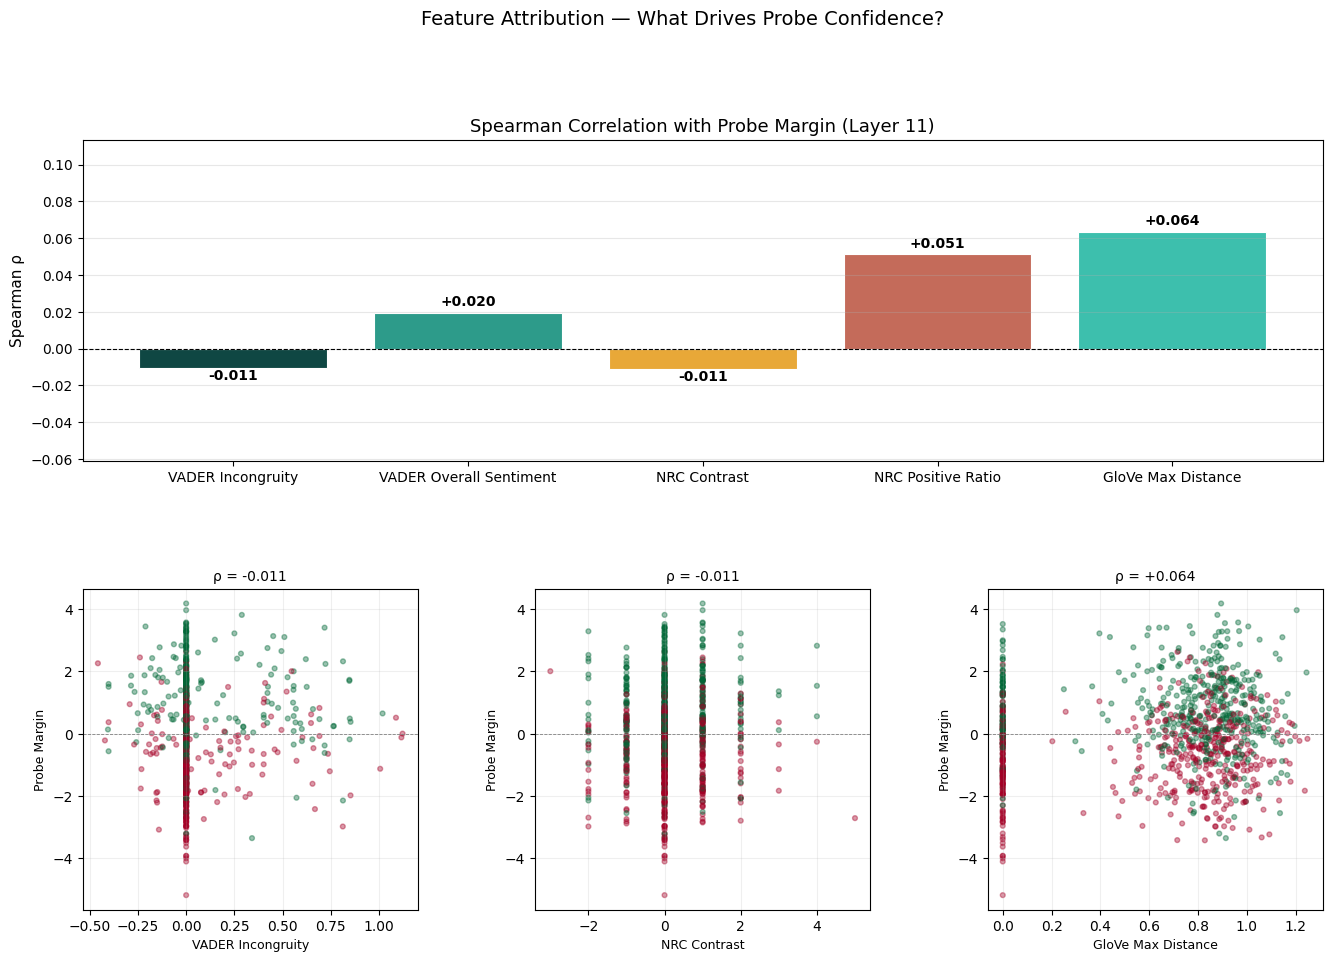

Plot saved.


In [38]:
# ── 10. Visualisation ────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = ['#0F4743', '#2D9B8A', '#E8A838', '#C46B5A', '#3DBFAD']

# ── (a) Bar chart of Spearman rho values ────────────────────
ax0 = fig.add_subplot(gs[0, :])
feature_names = corr_df['feature'].tolist()
rho_vals      = corr_df['spearman_rho'].tolist()
bar_colors    = [colors[i] for i in range(len(feature_names))]

bars = ax0.bar(feature_names, rho_vals, color=bar_colors,
               edgecolor='white', linewidth=0.8)
ax0.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax0.set_title(
    f'Spearman Correlation with Probe Margin (Layer {best_layer})',
    fontsize=13
)
ax0.set_ylabel('Spearman ρ', fontsize=11)
ax0.set_ylim(min(rho_vals) - 0.05, max(rho_vals) + 0.05)
for bar, val in zip(bars, rho_vals):
    ax0.text(bar.get_x() + bar.get_width()/2,
             val + (0.002 if val >= 0 else -0.008),
             f'{val:+.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax0.grid(axis='y', alpha=0.3)

# ── (b-f) Scatter plots: each feature vs probe margin ───────
scatter_features = [
    ('VADER Incongruity',       'vader_incongruity'),
    ('NRC Contrast',            'nrc_contrast'),
    ('GloVe Max Distance',      'glove_max_dist'),
    ('VADER Overall Sentiment', 'vader_overall'),
    ('NRC Positive Ratio',      'nrc_pos_ratio'),
]

scatter_positions = [
    gs[1, 0], gs[1, 1], gs[1, 2]
]

# Just plot first 3 to fit the grid
for idx, (fname, col) in enumerate(scatter_features[:3]):
    ax = fig.add_subplot(scatter_positions[idx])

    # Sample 1000 points for readability
    sample = dataset.sample(1000, random_state=RANDOM_SEED)
    sc = ax.scatter(
        sample[col], sample['probe_margin'],
        c=sample['label'], cmap='RdYlGn',
        alpha=0.4, s=12
    )

    rho = corr_df.loc[
        corr_df['column']==col, 'spearman_rho'
    ].values[0]

    ax.set_xlabel(fname, fontsize=9)
    ax.set_ylabel('Probe Margin', fontsize=9)
    ax.set_title(f'ρ = {rho:+.3f}', fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax.grid(alpha=0.2)

plt.suptitle(
    'Feature Attribution — What Drives Probe Confidence?',
    fontsize=14, y=1.01
)

plt.savefig(SAVE_PATH + 'feature_attribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [39]:
# ── 11. Compare feature distributions: sarcastic vs literal ──
print("Mean feature values by label:")
print("=" * 55)
compare = dataset.groupby('label')[
    ['vader_incongruity', 'vader_overall',
     'nrc_contrast', 'nrc_pos_ratio', 'glove_max_dist']
].mean().round(4)
compare.index = ['Literal (0)', 'Sarcastic (1)']
print(compare.to_string())
print()

# T-test to check if differences are significant
from scipy.stats import ttest_ind
print("T-tests: sarcastic vs literal")
print("-" * 45)
for col, name in [
    ('vader_incongruity', 'VADER Incongruity'),
    ('nrc_contrast',      'NRC Contrast'),
    ('glove_max_dist',    'GloVe Max Distance'),
]:
    sarc_vals = dataset.loc[dataset['label']==1, col]
    lit_vals  = dataset.loc[dataset['label']==0, col]
    t, p = ttest_ind(sarc_vals, lit_vals)
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"{name:<25}  t={t:.3f}  p={p:.4e}  {sig}")

Mean feature values by label:
               vader_incongruity  vader_overall  nrc_contrast  nrc_pos_ratio  glove_max_dist
Literal (0)               0.0448         0.0597        0.1348         0.2772          0.6249
Sarcastic (1)             0.0572         0.0614        0.1424         0.3019          0.6746

T-tests: sarcastic vs literal
---------------------------------------------
VADER Incongruity          t=3.122  p=1.8034e-03  ✓ significant
NRC Contrast               t=0.417  p=6.7693e-01  ✗ not significant
GloVe Max Distance         t=6.503  p=8.2255e-11  ✓ significant
